In [1]:
import pandas as pd
import numpy as np
from collections import Counter, defaultdict
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import pandas as pd
# from upsetplot import from_memberships, UpSet
import matplotlib.pyplot as plt

import math
import plotly.express as px


In [2]:
df = pd.read_csv("../data/papers.csv")
total_papers = len(df)
df.columns


Index(['Title', 'Database', 'Year', 'Month', 'Journal or Conference',
       'Paper Type', 'Data Source', 'Data Country', 'Data Domain',
       'Data Language', 'Data Availability', 'Link to Data', 'Data Details',
       'Size', 'Number of Prompts If Applicable', 'Medical Application',
       'Task Type', 'Topic', 'Note', 'Bias Evaluation Metric',
       'Bias Definition', 'Conclusions', 'Race or Ethnic Bias', 'Gender Bias',
       'Language Bias', 'Age Bias', 'Other Bias', 'LGBTQ+ Bias',
       'Disability Bias', 'Geography or Cultural Bias', 'Evaluated LLMs',
       'Reference Standard', 'Patient Inclusion', 'Has Debiasing',
       'Debias Focus', 'Debiasing Method', 'Debias Details'],
      dtype='str')

In [3]:
llms_lst = df["Evaluated LLMs"].dropna().tolist()

freq_mp = Counter(
    model.strip()
    for entry in llms_lst
    for model in entry.split(",")
)

In [4]:
# ChatGPT
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3.5']
freq_mp["ChatGPT"] += freq_mp['GPT-4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4.0']
freq_mp["ChatGPT"] += freq_mp['GPT-4o-mini']
freq_mp["ChatGPT"] += freq_mp['GPT-4o']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4o']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3.5-turbo']
freq_mp["ChatGPT"] += freq_mp['GPT-4 Turbo']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5 Turbo']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 3.5']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 4.0']
freq_mp["ChatGPT"] += freq_mp['OpenAI’s GPT-4']
freq_mp["ChatGPT"] += freq_mp['OpenAI’s ChatGPT May 12 and\nAugust 3 versions']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5-Turbo']
freq_mp["ChatGPT"] += freq_mp['COT-ChatGPT-4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-4.5']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 4o']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3.5-Turbo']
freq_mp["ChatGPT"] += freq_mp['GPT-3.5-turbo']
freq_mp["ChatGPT"] += freq_mp['GPT3.5-turbo']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-2']
freq_mp["ChatGPT"] += freq_mp['ChatGPT4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT3.5']
freq_mp["ChatGPT"] += freq_mp['GPT-4-o']
freq_mp["ChatGPT"] += freq_mp['ChatGPT-3']
freq_mp["ChatGPT"] += freq_mp['GPT‑2']
freq_mp["ChatGPT"] += freq_mp['ChatGPT (3.5 versions May 12']
freq_mp["ChatGPT"] += freq_mp['GPT‑4']
freq_mp["ChatGPT"] += freq_mp['ChatGPT 4o']
freq_mp["ChatGPT"] += freq_mp["ChatGPT-3.5-Turbo"]
freq_mp["ChatGPT"] += freq_mp["ChatGPT GPT-4"]
freq_mp["ChatGPT"] += freq_mp["GPT-3"]
freq_mp["ChatGPT"] += freq_mp["ChatGPT (GPT-3.5 version)"]
freq_mp["ChatGPT"] += freq_mp["ChatGPT (unspecified version)"]
freq_mp["ChatGPT"] += freq_mp["GPT-2"]
freq_mp["ChatGPT"] += freq_mp["ChatGPT‑4o"]
freq_mp["ChatGPT"] += freq_mp["Agent-ChatGPT-4"]
freq_mp["ChatGPT"] += freq_mp["GPT-3.5-Turbo and GPT-4"] + 1
freq_mp["ChatGPT"] += freq_mp['ChatGPT GPT‑3.5‑Turbo‑0301']

del freq_mp['ChatGPT-4']
del freq_mp['ChatGPT-3.5']
del freq_mp['GPT-4']
del freq_mp['ChatGPT-4.0']
del freq_mp['GPT-4o-mini']
del freq_mp['GPT-4o']
del freq_mp['ChatGPT-4o']
del freq_mp['GPT-3.5']
del freq_mp['ChatGPT-3.5-turbo']
del freq_mp['GPT-4 Turbo']
del freq_mp['GPT-3.5 Turbo']
del freq_mp['ChatGPT 3.5']
del freq_mp['ChatGPT 4.0']
del freq_mp['OpenAI’s GPT-4']
del freq_mp['OpenAI’s ChatGPT May 12 and\nAugust 3 versions']
del freq_mp['GPT-3.5-Turbo']
del freq_mp['COT-ChatGPT-4']
del freq_mp['ChatGPT-4.5']
del freq_mp['GPT-3.5-turbo']
del freq_mp['GPT3.5-turbo']
del freq_mp['ChatGPT-2']
del freq_mp['ChatGPT4']
del freq_mp['ChatGPT3.5']
del freq_mp['GPT-4-o']
del freq_mp['ChatGPT-3']
del freq_mp['GPT‑2']
del freq_mp['ChatGPT (3.5 versions May 12']
del freq_mp['GPT‑4']
del freq_mp['ChatGPT 4o']
del freq_mp["ChatGPT-3.5-Turbo"]
del freq_mp["ChatGPT GPT-4"]
del freq_mp["GPT-3"]
del freq_mp["ChatGPT (GPT-3.5 version)"]
del freq_mp["ChatGPT (unspecified version)"]
del freq_mp["GPT-2"]
del freq_mp["ChatGPT‑4o"]
del freq_mp["Agent-ChatGPT-4"]
del freq_mp["GPT-3.5-Turbo and GPT-4"]
del freq_mp['ChatGPT GPT‑3.5‑Turbo‑0301']


# Gemini
freq_mp["Gemini"] += freq_mp['Gemini 1.5 Flash']
freq_mp["Gemini"] += freq_mp['Gemini-1.5-Flash']
freq_mp["Gemini"] += freq_mp['Gemini-1.0-pro']
freq_mp["Gemini"] += freq_mp['Gemini-3.5-Flash)']
freq_mp["Gemini"] += freq_mp["Gemini 1.5 Pro"]

del freq_mp['Gemini 1.5 Flash']
del freq_mp['Gemini-1.5-Flash']
del freq_mp['Gemini-1.0-pro']
del freq_mp['Gemini-3.5-Flash)']
del freq_mp["Gemini 1.5 Pro"]


# Llama
freq_mp["Llama"] += freq_mp["Llama-2 (13b)"]
freq_mp["Llama"] += freq_mp["Llama-2 (7b)"]
freq_mp["Llama"] += freq_mp['Llama-3.1-8B']
freq_mp["Llama"] += freq_mp['Llama-3.1-70B']
freq_mp["Llama"] += freq_mp['Llama3-70b']
freq_mp["Llama"] += freq_mp['LLama3-70B']
freq_mp["Llama"] += freq_mp['Llama3.1-403B']
freq_mp["Llama"] += freq_mp['Llama3.1-403B']
freq_mp["Llama"] += freq_mp['LLaMA-2']
freq_mp["Llama"] += freq_mp['COT-LLaMA-3 60 56 52 66\nSFT-LoRA']
freq_mp["Llama"] += freq_mp['Llama-3-70b']
freq_mp["Llama"] += freq_mp['Llama-3.1-Instruct-8B']
freq_mp["Llama"] += freq_mp['Llama-3.1-Instruct-70B']
freq_mp["Llama"] += freq_mp['Llama-3.2-3B Instruct']
freq_mp["Llama"] += freq_mp['Llama3-Med42-8B']
freq_mp["Llama"] += freq_mp["Llama3-8B"]
freq_mp["Llama"] += freq_mp["and Llama3-8B"]
freq_mp["Llama"] += freq_mp["LLaMA-3.2-3B-Instruct"]
freq_mp["Llama"] += freq_mp["Llama-3.1-8B-Instruct"]
freq_mp["Llama"] += freq_mp["LLaMA-3.2"]
freq_mp["Llama"] += freq_mp["Llama3-I-70B"]
freq_mp["Llama"] += freq_mp["Llama3-I-8B"]
freq_mp["Llama"] += freq_mp["LLaMA-3.2"]
freq_mp["Llama"] += freq_mp["Llama 2-13B"]
freq_mp["Llama"] += freq_mp["LLaMA"]

del freq_mp["Llama-2 (13b)"]
del freq_mp["Llama-2 (7b)"]
del freq_mp['Llama-3.1-8B']
del freq_mp['Llama-3.1-70B']
del freq_mp['Llama3-70b']
del freq_mp['LLama3-70B']
del freq_mp['Llama3.1-403B']
del freq_mp['Llama3.1-403B']
del freq_mp['LLaMA-2']
del freq_mp['COT-LLaMA-3 60 56 52 66\nSFT-LoRA']
del freq_mp['Llama-3-70b']
del freq_mp['Llama-3.1-Instruct-8B']
del freq_mp['Llama-3.1-Instruct-70B']
del freq_mp['Llama-3.2-3B Instruct']
del freq_mp['Llama3-Med42-8B']
del freq_mp["Llama3-8B"]
del freq_mp["and Llama3-8B"]
del freq_mp["LLaMA-3.2-3B-Instruct"]
del freq_mp["Llama-3.1-8B-Instruct"]
del freq_mp["Llama3-I-70B"]
del freq_mp["Llama3-I-8B"]
del freq_mp["LLaMA-3.2"]
del freq_mp["Llama 2-13B"]
del freq_mp["LLaMA"]


# Claude  
freq_mp["Claude"] += freq_mp["COT-Claude-3"]
freq_mp["Claude"] += freq_mp["Anthropic’s Claude May 15 and\nAugust 3 versions"]
freq_mp["Claude"] += freq_mp["Claude 3 Haiku"]
freq_mp["Claude"] += freq_mp["Haiku"]
freq_mp["Claude"] += freq_mp["Claude-3-5-sonnet-20240620"]
freq_mp["Claude"] += freq_mp["Claude (May 15"]
freq_mp["Claude"] += freq_mp["Claude 3.5 Sonnet"]

del freq_mp["COT-Claude-3"]
del freq_mp["Anthropic’s Claude May 15 and\nAugust 3 versions"]
del freq_mp["Claude 3 Haiku"]
del freq_mp["Haiku"]
del freq_mp["Claude-3-5-sonnet-20240620"]
del freq_mp["Claude-3.5-Sonnet"]
del freq_mp["Claude (May 15"]
del freq_mp["Claude 3.5 Sonnet"]


# Qwen
freq_mp["Qwen"] += freq_mp['Qwen2-7B']
freq_mp["Qwen"] += freq_mp['Qwen2-72B']
freq_mp["Qwen"] += freq_mp['Qwen-turbo']
freq_mp["Qwen"] += freq_mp['Qwen1.5-72b']
freq_mp["Qwen"] += freq_mp['Qwen1.5-70B-Chat']
freq_mp["Qwen"] += freq_mp['Qwen1.5-70B-Chat']
freq_mp["Qwen"] += freq_mp['Qwen1.5-7B-Chat']
freq_mp["Qwen"] += freq_mp['Qwen1.5-7B-SFT']
freq_mp["Qwen"] += freq_mp['Qwen2.5-Instruct-7B and Qwen2.5-Instruct-72B']
freq_mp["Qwen"] += freq_mp['Qwen-14B']

del freq_mp['Qwen2-7B']
del freq_mp['Qwen2-72B']
del freq_mp['Qwen-turbo']
del freq_mp['Qwen1.5-72b']
del freq_mp['Qwen1.5-70B-Chat']
del freq_mp['Qwen1.5-70B-Chat']
del freq_mp['Qwen1.5-7B-Chat']
del freq_mp['Qwen1.5-7B-SFT']
del freq_mp['Qwen2.5-Instruct-7B and Qwen2.5-Instruct-72B']
del freq_mp['Qwen-14B']

# Mistral
freq_mp["Mistral"] += freq_mp["Mistral (7b)"]
freq_mp["Mistral"] += freq_mp["Mistral-7B-v0.1"]
freq_mp["Mistral"] += freq_mp["Mistral-7B"]
freq_mp["Mistral"] += freq_mp["Mistral-I-7B"]
freq_mp["Mistral"] += freq_mp["mistralai/Mistral-Small-Instruct-2409"]
freq_mp["Mistral"] += freq_mp["Mistral-Large-Instruct-2407"]
freq_mp["Mistral"] += freq_mp["Mistral-del"]

del freq_mp["Mistral (7b)"]
del freq_mp["Mistral-7B-v0.1"]
del freq_mp["Mistral-7B"]
del freq_mp["Mistral-I-7B"]
del freq_mp["mistralai/Mistral-Small-Instruct-2409"]
del freq_mp["Mistral-Large-Instruct-2407"]
del freq_mp["Mistral-del"]

# Gemma
freq_mp["Gemma"] += freq_mp["Gemma-2-27B"]
freq_mp["Gemma"] += freq_mp["Gemma-2-9B-it"]
freq_mp["Gemma"] += freq_mp["Gemma-3"]

del freq_mp["Gemma-2-27B"]
del freq_mp["Gemma-2-9B-it"]
del freq_mp["Gemma-3"]

# Phi
freq_mp["Phi"] += freq_mp["Phi-3.5-mini-instruct"]
freq_mp["Phi"] += freq_mp["Phi-3-medium-128k-instruct"]

del freq_mp["Phi-3.5-mini-instruct"]
del freq_mp["Phi-3-medium-128k-instruct"]

# BioMistral
freq_mp["BioMistral"] += freq_mp["BioMistral-7B"]

del freq_mp["BioMistral-7B"]

# Bard 
freq_mp["Bard"] += freq_mp["Google’s Bard May 18\nand August 3 version"]
freq_mp["Bard"] += freq_mp["Google-Bard"]
freq_mp["Bard"] += freq_mp["Bard (May 18"]
freq_mp["Bard"] += freq_mp["Google Bard"]

del freq_mp["Google’s Bard May 18\nand August 3 version"]
del freq_mp["Google-Bard"]
del freq_mp["Bard (May 18"]
del freq_mp["Google Bard"]


# Bing
freq_mp["Bing"] += freq_mp["Bing AI"]
freq_mp["Bing"] += freq_mp["Bing-Chat"]
freq_mp["Bing"] += freq_mp["Bing-Chat"]
freq_mp["Bing"] += freq_mp["BingChat"]
freq_mp["Bing"] += freq_mp["Microsoft Bing"]
freq_mp["Bing"] += freq_mp["Microsoft’s Bing A.I. Image Creator"]

del freq_mp["Bing AI"]
del freq_mp["Bing-Chat"]
del freq_mp["Bing-Chat"]
del freq_mp["BingChat"]
del freq_mp["Microsoft Bing"]
del freq_mp["Microsoft’s Bing A.I. Image Creator"]


# Baichuan
freq_mp["Baichuan"] += freq_mp["Baichuan2-turbo"]

del freq_mp["Baichuan2-turbo"]


# Olmo
freq_mp["Olmo"] += freq_mp["OLMo-7B-Instruct"]
freq_mp["Olmo"] += freq_mp["and OLMo-2-0325-32B-Instruct"]

del freq_mp["OLMo-7B-Instruct"]
del freq_mp["and OLMo-2-0325-32B-Instruct"]


freq_mp["OpenBioLLM"] += freq_mp["OpenBioLLM-8B"]
freq_mp["OpenBioLLM"] += freq_mp["OpenBioLLM-70B"]

del freq_mp["OpenBioLLM-8B"]
del freq_mp["OpenBioLLM-70B"]


# UltraMedicalLLM 
freq_mp["UltraMedicalLLM"] += freq_mp["UltraMedicalLLM-8B"]
freq_mp["UltraMedicalLLM"] += freq_mp["UltraMedicalLLM-70B"]

del freq_mp["UltraMedicalLLM-8B"]
del freq_mp["UltraMedicalLLM-70B"]


# Yi-Chat
freq_mp["Yi-Chat"] += freq_mp["Yi-Chat-34B"]
freq_mp["Yi-Chat"] += freq_mp["Yi-Chat-34B"]
freq_mp["Yi-Chat"] += freq_mp["Yi-34B"]
freq_mp["Yi-Chat"] += freq_mp["Yi-Chat-6B"]

del freq_mp["Yi-Chat-34B"]
del freq_mp["Yi-Chat-34B"]
del freq_mp["Yi-34B"]
del freq_mp["Yi-Chat-6B"]


# HuatuoGPT
freq_mp["HuatuoGPT"] += freq_mp["HuatuoGPT2-34B"]
freq_mp["HuatuoGPT"] += freq_mp["HuatuoGPT2-13B"]

del freq_mp["HuatuoGPT2-34B"]
del freq_mp["HuatuoGPT2-13B"]

# Ziya
freq_mp["Ziya"] += freq_mp["Ziya-7B"]

del freq_mp["Ziya-7B"]


# Meditron
freq_mp["Meditron"] += freq_mp["Meditron-3-8B"]
freq_mp["Meditron"] += freq_mp["Meditron-3-70B"]

del freq_mp["Meditron-3-8B"]
del freq_mp["Meditron-3-70B"]


# AceGPT
freq_mp["AceGPT"] += freq_mp["AceGPT-7B"]
freq_mp["AceGPT"] += freq_mp["AceGPT-13B"]

del freq_mp["AceGPT-7B"]
del freq_mp["AceGPT-13B"]

In [5]:
gpt = [
    "ChatGPT", "ChatGPT-3", "GPT-3", "ChatGPT3.5", "ChatGPT 3.5", "ChatGPT-3.5", "ChatGPT-3.5-turbo",
    "ChatGPT-3.5-Turbo", "ChatGPT GPT-3.5-Turbo-0301", "GPT-3.5", "GPT-3.5-turbo",
    "GPT-3.5 Turbo", "GPT-3.5-Turbo", "GPT3.5-turbo", "ChatGPT (GPT-3.5 version)",
    "ChatGPT (3.5 versions May 12", "ChatGPT-4", "ChatGPT-4.0", "ChatGPT 4.0", "ChatGPT4",
    "ChatGPT-4.5", "ChatGPT-4o", "ChatGPT 4o", "ChatGPT-4o", "ChatGPT\u20114o", "ChatGPT-4o-mini",
    "GPT-4", "GPT-4", "GPT-4 Turbo",
    "GPT-4o", "GPT-4o-mini", "GPT-4-o", "OpenAI’s GPT-4", "ChatGPT GPT-4", "COT-ChatGPT-4",
    "Agent-ChatGPT-4", "GPT-3.5-Turbo and GPT-4", "ChatGPT-2", "GPT-2", "GPT-2",
    "Stanford Medicine Secure GPT",
]

gemini = [
    "Gemini", "Gemini 1.5 Flash", "Gemini-1.5-Flash", "Gemini-1.0-pro", "Gemini 1.5 Pro",
    "Gemini-3.5-Flash", "Gemini-3.5-Flash)",
]


llama = [
    "LLaMA", "LLaMA-2", "Llama-2 (13b)", "Llama-2 (7b)", "Llama 2-13B", "Llama-3.1-8B", 
    "Llama-3.1-70B", "Llama3-70b", "LLama3-70B", "Llama3.1-403B", "Llama-3-70b", 
    "Llama-3.1-Instruct-8B", "Llama-3.1-Instruct-70B", "Llama-3.2-3B Instruct", 
    "Llama3-Med42-8B", "Llama3-8B", "and Llama3-8B", "LLaMA-3.2-3B-Instruct", 
    "Llama-3.1-8B-Instruct", "LLaMA-3.2", "Llama3-I-70B", "Llama3-I-8B", 
    "COT-LLaMA-3 60 56 52 66\nSFT-LoRA", "Llama-3.1-8B", "Llama-3.1-70B", "Llama3-70b", 
    "LLama3-70B", "Llama3.1-403B", "Llama-3-70b", "Llama-3.1-Instruct-8B", 
    "Llama-3.1-Instruct-70B", "Llama-3.2-3B Instruct", "Llama3-Med42-8B", "Llama3-8B", 
    "and Llama3-8B", "LLaMA-3.2-3B-Instruct", "Llama-3.1-8B-Instruct", "LLaMA-3.2", 
    "Llama3-I-70B", "Llama3-I-8B", "COT-LLaMA-3 60 56 52 66\nSFT-LoRA",
]


claude = [
    "COT-Claude-3", "Claude 3 Haiku", "Haiku", "Claude-3-5-sonnet-20240620",
    "Claude 3.5 Sonnet", "Claude-3.5-Sonnet",
]

qwen = [
    "Qwen-turbo", "Qwen1.5-72b", "Qwen1.5-70B-Chat", "Qwen1.5-70B-Chat", "Qwen1.5-7B-Chat",
    "Qwen1.5-7B-SFT", "Qwen-14B", "Qwen2-7B", "Qwen2-72B",
]

mistral = [
    "Mistral (7b)", "Mistral-7B-v0.1", "Mistral-7B", "Mistral-I-7B", 
    "mistralai/Mistral-Small-Instruct-2409", "Mistral-Large-Instruct-2407", "Mistral-del",
]

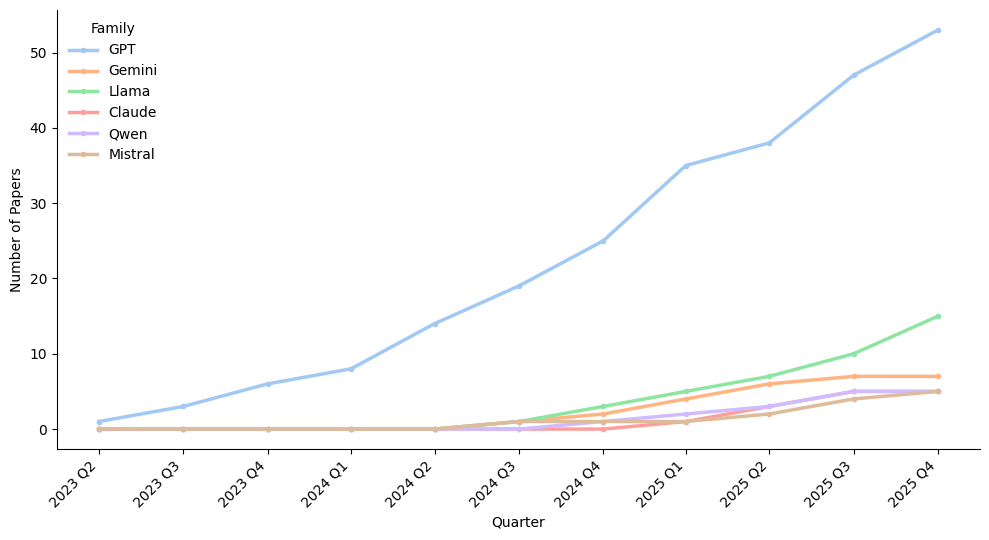

In [6]:
model_groups = {
    "GPT": gpt, "Gemini": gemini, "Llama": llama,
    "Claude": claude, "Qwen": qwen, "Mistral": mistral,
}

model_to_family = {}
for family, names in model_groups.items():
    for name in names:
        model_to_family[name] = family

family_order = ["GPT", "Gemini", "Llama", "Claude", "Qwen", "Mistral"]

plot_df = df.copy()
plot_df["_date"] = pd.to_datetime(
    plot_df["Month"].astype(str) + " " + plot_df["Year"].astype(str),
    format="%B %Y",
    errors="coerce",
)
plot_df = plot_df[plot_df["_date"].notna() & plot_df["Evaluated LLMs"].notna()].copy()
plot_df["quarter"] = plot_df["_date"].dt.to_period("Q")

records = []
for _, row in plot_df.iterrows():
    q = row["quarter"]
    families = set()
    for raw in str(row["Evaluated LLMs"]).split(","):
        name = raw.strip()
        fam = model_to_family.get(name)
        if fam is not None:
            families.add(fam)
    for fam in families:
        records.append({"quarter": q, "family": fam})

quarterly = (
    pd.DataFrame(records)
    .groupby(["quarter", "family"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(columns=family_order, fill_value=0)
    .sort_index()
)
cumulative = quarterly.cumsum()
quarter_end = cumulative.index.to_timestamp(how="end")

import seaborn as sns

_palette = sns.color_palette("pastel", n_colors=len(family_order))
_colors = dict(zip(family_order, _palette))

fig, ax = plt.subplots(figsize=(10, 5.5))
for fam in family_order:
    if fam in cumulative.columns:
        ax.plot(
            quarter_end,
            cumulative[fam],
            marker="o",
            markersize=3,
            linewidth=2.5,
            label=fam,
            color=_colors[fam],
        )

ax.set_xlabel("Quarter")
ax.set_ylabel("Number of Papers")
ax.legend(title="Family", frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks(quarter_end)
ax.set_xticklabels([f"{p.year} Q{p.quarter}" for p in cumulative.index], rotation=45, ha="right")
fig.tight_layout()
fig.savefig("model_families_cumulative_quarterly.png", dpi=200, bbox_inches="tight")
plt.show()

/var/folders/04/2hwl1j9x5yl1hdpnd9k3jlqw0000gn/T/ipykernel_85826/3018089737.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), rotation=label_rotation, ha="right")


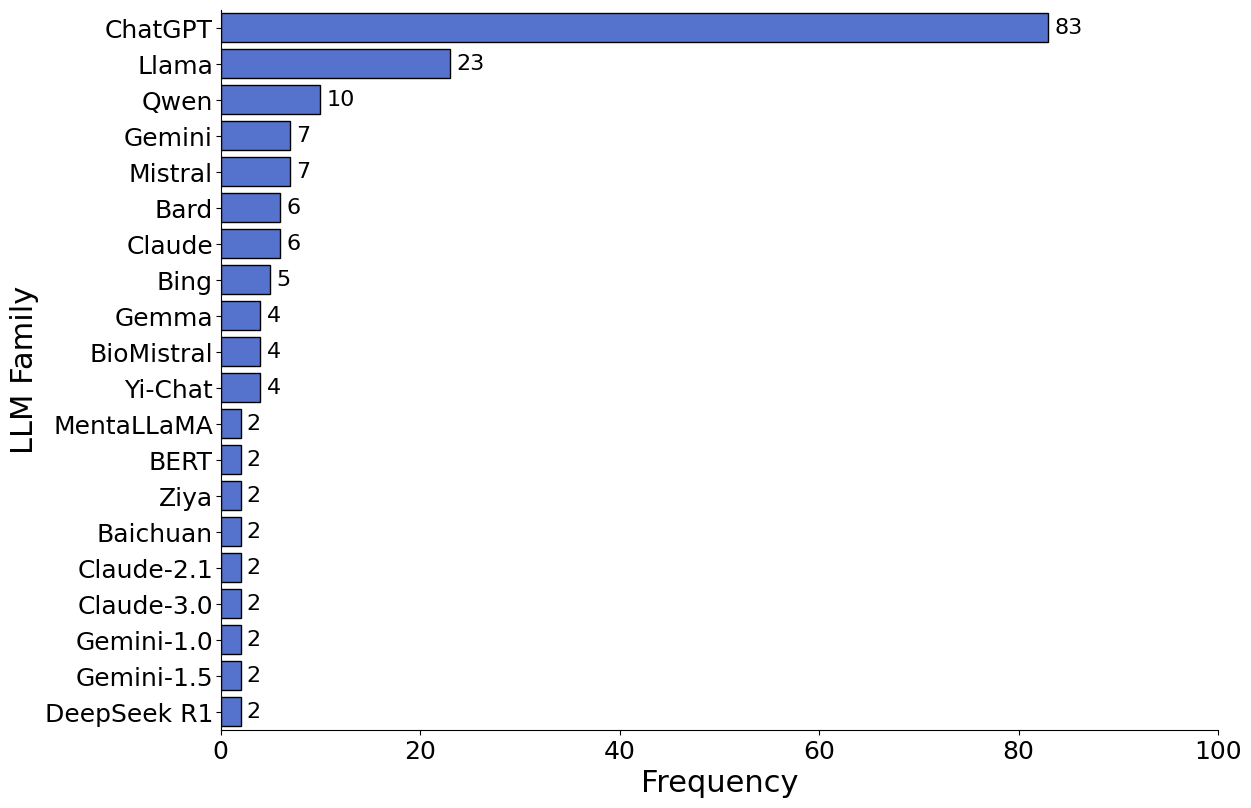

In [7]:
import seaborn as sns

label_rotation = 0
x_tick_labelsize = 18
SHOW_AXIS_TITLES = True
axis_title_fontsize = 22
count_label_pad = 0.6
count_label_fontsize = 16
SAVE_SVG = True
svg_path = "llms_evaluated_frequency.svg"

MIN_COUNT = 2
DROP_LLMS = {
    "Phi",
    "Olmo",
    "OpenBioLLM",
    "UltraMedicalLLM",
    "HuatuoGPT",
    "Meditron",
    "AceGPT",
}

llm_freqs = dict(
    sorted(
        (
            (k, v)
            for k, v in freq_mp.items()
            if v >= MIN_COUNT and k not in DROP_LLMS
        ),
        key=lambda kv: kv[1],
        reverse=True,
    )
)

llms = list(llm_freqs.keys())
counts = list(llm_freqs.values())
plot_df = pd.DataFrame({"llm": llms, "count": counts})

n_cats = len(llms)
fig, ax = plt.subplots(figsize=(12, max(8, 0.38 * n_cats)))

sns.barplot(
    data=plot_df,
    y="llm",
    x="count",
    ax=ax,
    color="royalblue",
    edgecolor="black",
    linewidth=1,
    order=plot_df["llm"],
)

sns.despine(ax=ax)

xmax_plot = int(math.ceil(max(counts) / 10.0)) * 10 + 10
x_step = 20 if xmax_plot >= 60 else 10
x_gap = count_label_pad

for i, count in enumerate(counts):
    ax.text(count + x_gap, i, f"{count}", ha="left", va="center", fontsize=count_label_fontsize)

ax.set_xlim(0, xmax_plot)
ax.set_xticks(range(0, xmax_plot + 1, x_step))

if SHOW_AXIS_TITLES:
    ax.set_xlabel("Frequency", fontsize=axis_title_fontsize)
    ax.set_ylabel("LLM Family", fontsize=axis_title_fontsize, labelpad=4)

ax.tick_params(axis="x", labelsize=x_tick_labelsize)
ax.tick_params(axis="y", labelsize=x_tick_labelsize, pad=2)
ax.set_yticklabels(ax.get_yticklabels(), rotation=label_rotation, ha="right")

longest = max((len(str(t.get_text())) for t in ax.get_yticklabels()), default=10)
fig.subplots_adjust(
    left=min(0.38, max(0.11, 0.085 + 0.0058 * longest)),
    right=0.98,
    top=0.98,
    bottom=0.08,
)
if SAVE_SVG:
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
fig.savefig("llms_evaluated_frequency.png", dpi=200, bbox_inches="tight")
plt.show()